# **Классификация SI > медианы**

**Импортируем необходимые библиотеки**

In [1]:
!pip install -q catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 4.9 MB/s eta 0:00:00


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

from catboost import CatBoostClassifier

**Загружаем данные и разбиваем выборку**

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/nezhablack/project-on-drug-effictiveness/refs/heads/main/chemical_data.csv')

targets_to_exclude = [
    'IC50, mM', 'CC50, mM', 'SI', 'pIC50', 'pCC50', 'log_SI',
    'IC50_above_median', 'CC50_above_median', 'SI_above_median', 'SI_above_8'
]

X = df.drop(columns = targets_to_exclude)
y = df['SI_above_median']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

print(f'Train: X = {X_train.shape}, y = {y_train.shape}')
print(f'Test: X = {X_test.shape}, y = {y_test.shape}')
print(f'Распределение классов (train): 0 = {sum(y_train == 0)}, 1 = {sum(y_train == 1)}')
print(f'Распределение классов (test): 0 = {sum(y_test == 0)}, 1 = {sum(y_test == 1)}')

Train: X = (800, 139), y = (800,)
Test: X = (201, 139), y = (201,)
Распределение классов (train): 0 = 400, 1 = 400
Распределение классов (test): 0 = 101, 1 = 100


**Обучаем модели и подбираем гиперпараметры**

In [ ]:
pipelines_clf = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(random_state = 42, max_iter = 1000))
    ]),
    'SVC': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(random_state = 42, probability = True))
    ]),
    'RandomForest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(random_state = 42, n_jobs = -1))
    ]),
    'CatBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('model', CatBoostClassifier(random_state = 42, verbose = 0))
    ]),
}

param_grids_clf = {
    'LogisticRegression': {
        'model__C': [0.01, 0.1, 1.0, 10.0, 100.0],
        'model__penalty': ['l2']
    },
    'SVC': {
        'model__C': [0.1, 1, 10],
        'model__kernel': ['rbf', 'linear'],
        'model__gamma': ['scale', 'auto']
    },
    'RandomForest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [None, 10, 20],
        'model__min_samples_split': [2, 5]
    },
    'CatBoost': {
        'model__depth': [4, 6, 8],
        'model__iterations': [100, 300],
        'model__learning_rate': [0.05, 0.1],
        'model__l2_leaf_reg': [1, 3, 5]
    },
}

results_clf = []
best_clf_models = {}

print('Обучение классификаторов (GridSearchCV, cv=5)')

for name in pipelines_clf:
    print(f'{name}', end = ' ')
    grid = GridSearchCV(pipelines_clf[name], param_grids_clf[name], cv = 5, scoring = 'accuracy', n_jobs = -1)
    grid.fit(X_train, y_train)
    best_clf_models[name] = grid.best_estimator_

    y_pred = grid.best_estimator_.predict(X_test)
    y_pred_prob = grid.best_estimator_.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_pred_prob)

    results_clf.append({
        'Модель': name,
        'Лучшие гиперпараметры': str(grid.best_params_),
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-score': round(f1, 4),
        'ROC-AUC': round(roc, 4),
    })
    print(f'Accuracy = {acc:.4f}  F1 = {f1:.4f}  ROC-AUC = {roc:.4f}')

results_clf_df = (
    pd.DataFrame(results_clf)
    .sort_values('F1-score', ascending = False)
    .reset_index(drop = True)
)

print('Результаты классификации SI_above_median')
display(results_clf_df)

Обучение классификаторов (GridSearchCV, cv=5)
LogisticRegression Accuracy = 0.5572  F1 = 0.5436  ROC-AUC = 0.6228
SVC Accuracy = 0.7015  F1 = 0.6667  ROC-AUC = 0.7299
RandomForest Accuracy = 0.6617  F1 = 0.6344  ROC-AUC = 0.6878
CatBoost Accuracy = 0.6617  F1 = 0.6531  ROC-AUC = 0.6764
Результаты классификации SI_above_median


,Модель,Лучшие гиперпараметры,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,SVC,"{'model__C': 1, 'model__gamma': 'scale', 'mode...",0.7015,0.7500,0.60,0.6667,0.7299
1,CatBoost,"{'model__depth': 8, 'model__iterations': 100, ...",0.6617,0.6667,0.64,0.6531,0.6764
2,RandomForest,"{'model__max_depth': None, 'model__min_samples...",0.6617,0.6860,0.59,0.6344,0.6878
3,LogisticRegression,"{'model__C': 0.1, 'model__penalty': 'l2'}",0.5572,0.5579,0.53,0.5436,0.6228


Первое место по метрикам занял метод опорных векторов. Но важно обратить внимание на несоответствие метрик: Precision = 0.75, но Recall = 0.6. Это означает, что SVC работает консервативно - предсказывает класс 1 осторожно, и когда предсказывает, чаще оказывается прав. Но при этом 40% реально селективных соединений она пропускает (FN). Для задачи скрининга это нежелательно, так как пропускаются потенциально действенные соединения.

CatBoost занял второе место по F1 (F1 = 0.6531, ROC-AUC = 0.6764). Recall у CatBoost выше, чем у SVC. Это говорит о том, что модель реже пропускает селективные соединения. При этом ROC-AUC = 0.6764 ниже, чем у SVC (0.7299). Это говорит о том, что вероятностные предсказания SVC качественнее - его кривая лучше разделяет классы при любом пороге. При пороге 0.5 SVC лучше, но SVC жертвует Recall.

Снижение качества по всем метрикам - это подтверждение физического смысла: чем сложнее целевая переменная по своей природе, тем ниже потолок предсказуемости на тех же признаках.

**Визуализируем результаты по метрикам качества**

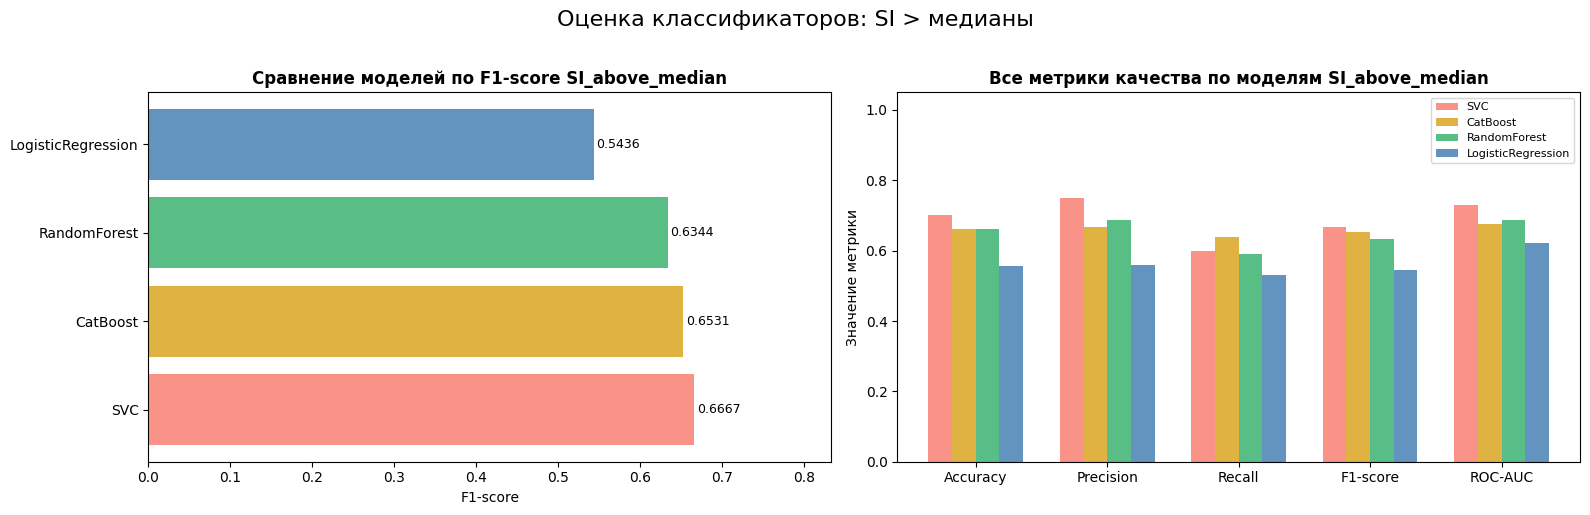

In [ ]:
model_colors = {
    'LogisticRegression': 'steelblue',
    'SVC': 'salmon',
    'RandomForest': 'mediumseagreen',
    'CatBoost': 'goldenrod',
}

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

#строим график по F1-score
bar_colors = [model_colors.get(m, 'gray') for m in results_clf_df['Модель']]
bars = axes[0].barh(results_clf_df['Модель'], results_clf_df['F1-score'], color = bar_colors, alpha = 0.85)
axes[0].set_xlabel('F1-score')
axes[0].set_title('Сравнение моделей по F1-score SI_above_median', fontweight = 'bold')
axes[0].set_xlim(0, max(results_clf_df['F1-score']) * 1.25)
for bar, val in zip(bars, results_clf_df['F1-score']):
    axes[0].text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2, f'{val:.4f}', va = 'center', fontsize = 9)

#строим график сравнения моделей по всем метрикам
x = np.arange(len(metrics))
n_models = len(results_clf_df)
width = 0.18
offsets = np.linspace(-(n_models-1)/2, (n_models-1)/2, n_models) * width

for i, (_, row) in enumerate(results_clf_df.iterrows()):
    vals = [row[m] for m in metrics]
    axes[1].bar(x + offsets[i], vals, width, label = row['Модель'], color = model_colors.get(row['Модель'], 'gray'),alpha = 0.85)

axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Все метрики качества по моделям SI_above_median', fontweight = 'bold')
axes[1].legend(fontsize = 8)
axes[1].set_ylabel('Значение метрики')

plt.suptitle('Оценка классификаторов: SI > медианы', fontsize = 16, y = 1.02)
plt.tight_layout()
plt.show()

Вывод: по метрикам SVC лидерует (Accuracy = 0.7, F1 = 0.67, ROC-AUC = 0.73). Однако Precision = 0.75, а Recall = 0.6. Это означает, что SVC работает консервативно - предсказывает высокий SI осторожно, и когда предсказывает, чаще оказывается прав. Но при этом 40% реально селективных соединений она пропускает (FN). Для задачи скрининга это нежелательно - пропущенные занчения безвозвратно теряются.

CatBoost занял второе место по F1 (F1 = 0.6531, ROC-AUC = 0.6764). Recall у CatBoost выше, чем у SVC (0.64) - модель реже пропускает селективные соединения. При этом ROC-AUC ниже, чем у SVC. Это говорит о том, что вероятностные предсказания SVC качественнее - его кривая лучше разделяет классы при любом пороге. При пороге 0.5 SVC лучше, но SVC жертвует Recall.

**Строим матрицы ошибок**

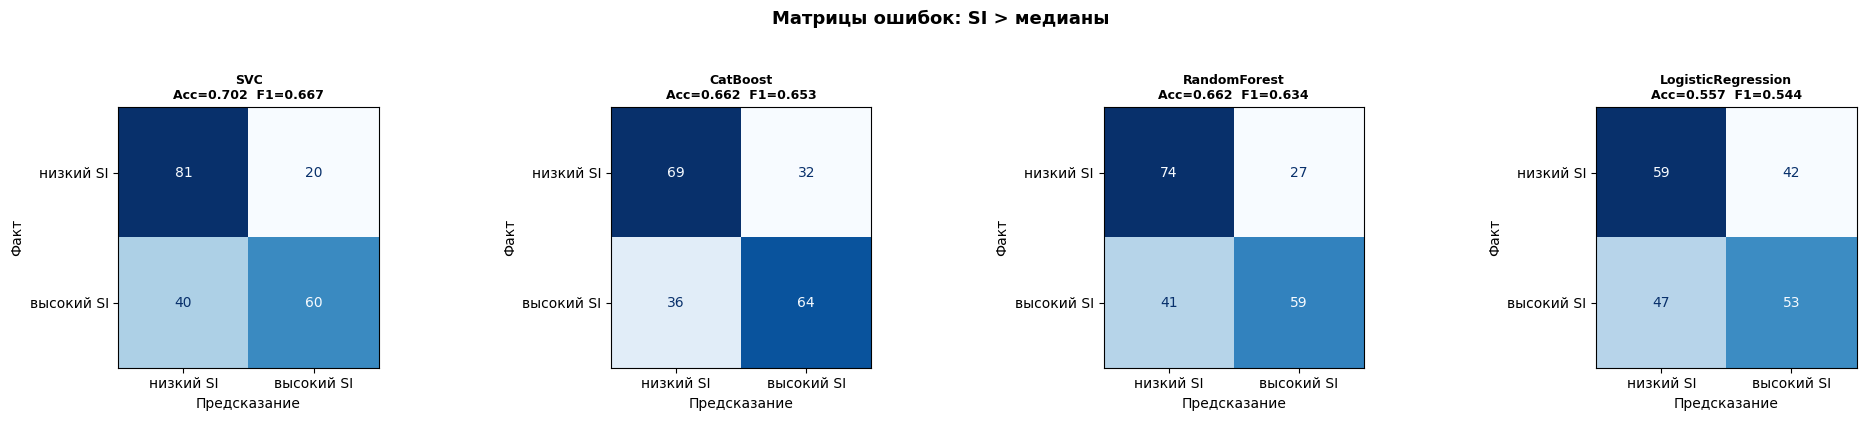

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (_, row) in zip(axes, results_clf_df.iterrows()):
    name = row['Модель']
    y_pred = best_clf_models[name].predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['низкий SI', 'высокий SI']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAcc={row["Accuracy"]:.3f}  F1={row["F1-score"]:.3f}',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Предсказание')
    ax.set_ylabel('Факт')

plt.suptitle('Матрицы ошибок: SI > медианы', fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('clf_SI_confusion.png', bbox_inches='tight', dpi=150)
plt.show()

Вывод: ни одна модель не справляется с классом 1 (высокой селективности SI) так же хорошо, как с классом 0. Лучший результат у CatBoost, 64 из 100 правильно классифицированных соединений с высоким SI. Это принципиальная проблема: именно класс 1 - целевой в задаче скрининга, и именно по нему качество хуже всего.

SVC имеет наименьшее число FP (20) и наибольшее число FN (40). Модель осторожна: она редко ошибочно называет соединение селективным, но при этом отбрасывает 40 из 100 реально селективных соединений. В химическом скрининге это очень низкий результат, потому что теряется 40% перспективных кандидатов. Высокая Accuracy = 0.702 создает ложное ощущение качества.

CatBoost в то же время пропускает меньше селективных соединений (FN = 36). Это лучший результат из всех четырех моделей. При этом 32 ложных предсказания, что вполне приемлемо - лишняя проверка соединения обходится дешевле, чем потеря активного кандидата. Для практической задачи скрининга CatBoost предпочтительнее SVC, несмотря на более низкий F1.

**Важность признаков: SVC vs CatBoost**

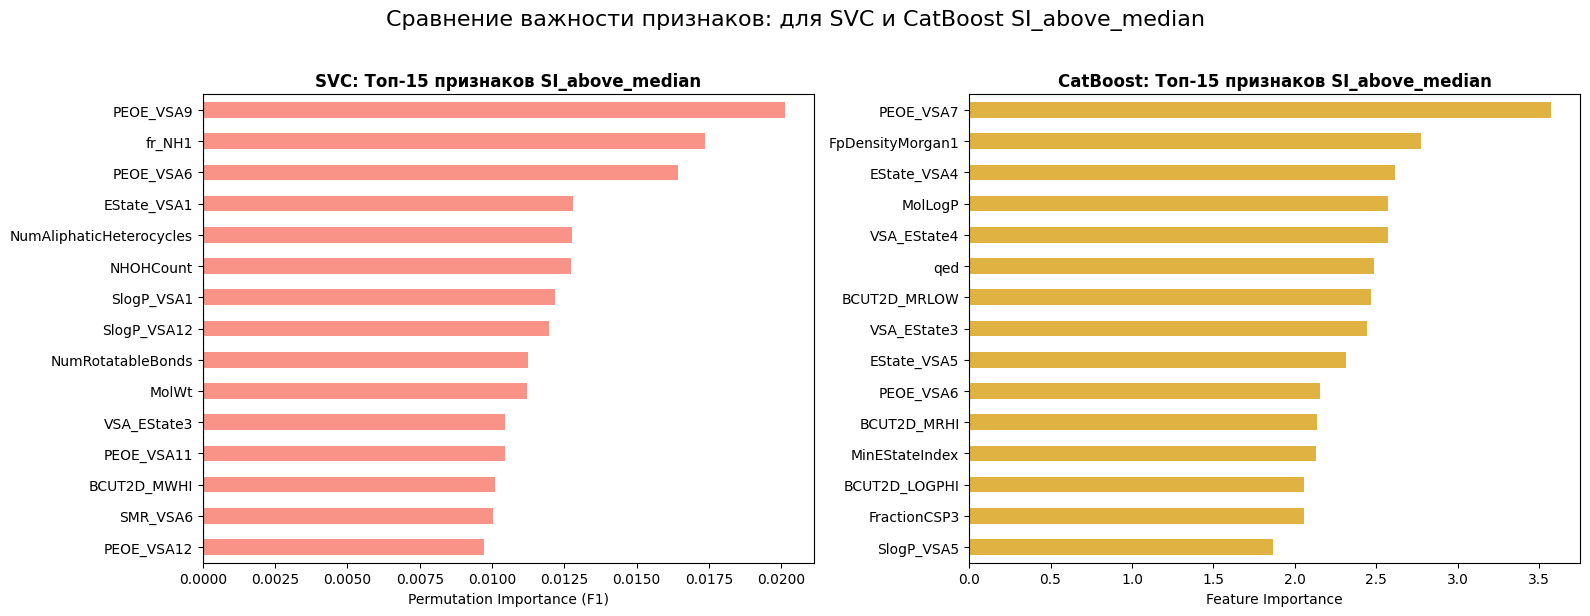

In [ ]:
#строим график важности признаков для CatBoost
cb_imp = pd.Series(best_clf_models['CatBoost'].named_steps['model'].get_feature_importance(), index = X.columns).sort_values(ascending = False).head(15)

#строим график важности признаков для SVC
perm = permutation_importance(best_clf_models['SVC'], X_test, y_test, n_repeats = 10, random_state = 42, scoring = 'f1', n_jobs = -1)
svc_imp = pd.Series(perm.importances_mean, index = X.columns).sort_values(ascending = False).head(15)

fig, axes = plt.subplots(1, 2, figsize = (16, 6))

svc_imp[::-1].plot(kind = 'barh', ax = axes[0], color = 'salmon', alpha = 0.85)
axes[0].set_title('SVC: Топ-15 признаков SI_above_median', fontweight = 'bold')
axes[0].set_xlabel('Permutation Importance (F1)')
axes[0].axvline(0, color = 'black', lw = 0.8, linestyle = '--')

cb_imp[::-1].plot(kind='barh', ax=axes[1], color = 'goldenrod', alpha = 0.85)
axes[1].set_title('CatBoost: Топ-15 признаков SI_above_median', fontweight = 'bold')
axes[1].set_xlabel('Feature Importance')

plt.suptitle('Сравнение важности признаков: для SVC и CatBoost SI_above_median', fontsize = 16, y = 1.02)
plt.tight_layout()
plt.show()

Оба графика демонстрируют, что VSA-дескрипторы (PEOE_VSA, SlogP_VSA, SMR_VSA, EState_VSA) занимают лидирующие позиции. Это молекулярные дескрипторы, которые  говорят о том, что форма молекулы и распределение заряда по поверхности критичны для прогнозирования SI. Эти признаки - наиболее надежные кандидаты для финальной модели, поскольку их значимость подтверждается разными методами оценки.

Отличающиеся признаки у двух моделей говорят о разных механизмах обучения: SVC чувствителен к линейным границам в пространстве признаков, CatBoost улавливает нелинейные взаимодействия.

**Итоговые выводы и рекомендации:**

Ни одна модель не может определить хотя бы 70% селективных соединений. Это означает, что применение любой из этих моделей в одиночку недостаточно. Необходимо использовать ансамбли с голосованием, либо использовать модель только как первичный фильтр, а дальше предоставлять специалистам-химикам вручную проверять отфильтрованные соединения.

**Рекомендации:**
- снизить порог SVC до 0.4 - это может увеличить Recall за счет незначительной потери Precision
- оптимизировать CatBoost через Optuna - текущие параметры (depth = 8, iterations = 100) указывают на возможное недообучение
- предсказывать pIC50 и pCC50 регрессией по отдельности, затем вычислять SI математически - это поможет обойти проблему накопления шума
- расширить датасет. Эта рекомендация остается главным резервом роста качества.